In [1]:
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize, LogNorm

# 1. plot noise spectra

In [2]:
hbar = 1/(2*np.pi)
kB = 8.617333262e-5  # eV K−1
hbar_in_eVs = 6.5821e-16  # eV s

def diel_spectral_density(omega, EC,temp_in_mK = 42 ,tangent_ref = 1e-5 ):

    beta = 1 / (kB * temp_in_mK * 1e-3)  # 1/eV

    coth_arg = beta * hbar_in_eVs * np.abs(omega) / 2  # s GHZ
    coth_arg *= 1e9  # dimensionless
    return_val = np.where(omega < 0, 
                          1/2 * np.abs( 1 / np.tanh(coth_arg) - 1) , 
                          1/2 * np.abs( 1 / np.tanh(coth_arg) + 1) )

    omega_ref = 2*np.pi *6 # GHz
    epsilon = 0.15
    Q_cap = 1/(  2* tangent_ref * np.abs(omega/omega_ref)**epsilon ) 

    return_val *= hbar * np.abs(omega)**2   / (4 * EC * Q_cap)  # GHZ^2/GHZ = GHZ


    return return_val

def one_over_f_spectral_density(omega, EL,one_over_f_flux_noise_amplitude ):
    return_val = 2 * np.pi # dimensionless
    return_val *= (EL / hbar)**2  # GHz^2
    return_val *= one_over_f_flux_noise_amplitude**2  # GHz^2
    return_val /= omega  # GHz
    return np.abs(return_val)

def T_phi(second_order_derivative, one_over_f_flux_noise_amplitude):  # eqn (13) of Peter Groszkowski et al 2018 New J. Phys. 20 043053
    omega_uv = 3 * 2 * np.pi  # GHz
    omega_ir = 1e-9 * 2 * np.pi  # GHz
    t = 10e3  # ns
    A = one_over_f_flux_noise_amplitude  # in unit of Phi0
    return_val = 2 * A**4 * second_order_derivative**2  # Phi0^4 GHZ^2 / Phi0^4
    return_val *= (np.log(omega_uv / omega_ir)**2 + 2 * np.log(omega_ir * t)**2)  # GHZ^2
    return_val = return_val**(-1/2)  # ns
    return return_val  # Seems the unit here should be millisecond? Where did miss a 1e3?


In [3]:
EJ = 3
EJ_over_EL_list = np.linspace(20,45,51)
EJ_over_EC_list = np.linspace(2,12,101)
X, Y = np.meshgrid(EJ_over_EC_list,EJ_over_EL_list)

import pickle
with open('data_v4_large_inductance.data', 'rb') as f:
    (EJ_over_EL_list, EJ_over_EC_list, EJ_over_EC_array, EJ_over_EL_array,
                 upside_down_phi_element01_array , upside_down_phi_element12_array ,
                   upside_down_freq01_array , upside_down_freq12_array ,
                     conventional_phi_element_array ,conventional_freq_array ,
                    upside_down_2nd_order_01_array ,upside_down_2nd_order_12_array ,conventional_2nd_order_array   ) = pickle.load(f)


frequencys = {
    "conventional":conventional_freq_array,
    "upside_down12":upside_down_freq12_array
}
phi_ele = {
    "conventional":conventional_phi_element_array,
    "upside_down12":upside_down_phi_element12_array
}

In [4]:
hbar = 1/(2*np.pi)

def compute_lifetimes(one_over_f_flux_noise_amplitude,
                      temp_in_mK, 
                      tangent_ref):
    conventional_dielectric_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    conventional_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    conventional_dephasing_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))

    upside_down01_dielectric_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down01_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down01_dephasing_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))

    upside_down12_dielectric_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down12_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down12_dephasing_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))

    for i in range(len(EJ_over_EL_list)):
        for j in range(len(EJ_over_EC_list)):
            EC = EJ / EJ_over_EC_list[j]
            EL = EJ / EJ_over_EL_list[i]

            # Conventional lifetimes
            omega_conventional = conventional_freq_array[i, j] * 2 * np.pi
            phi_conventional = conventional_phi_element_array[i, j]
            second_order_conventional = conventional_2nd_order_array[i, j] * 2 * np.pi

            conventional_dielectric_lifetime[i, j] = 1 / (np.abs(phi_conventional)**2 * diel_spectral_density(omega_conventional, EC,temp_in_mK,tangent_ref  ))
            conventional_one_over_f_loss_lifetime[i, j] = 1 / (np.abs(phi_conventional)**2 * one_over_f_spectral_density(omega_conventional, EL,one_over_f_flux_noise_amplitude )) 
            conventional_dephasing_lifetime[i, j] = T_phi(second_order_conventional, one_over_f_flux_noise_amplitude)

            # Upside down 12 lifetimes
            omega_upside_down12 = upside_down_freq12_array[i, j] * 2 * np.pi
            phi_upside_down12 = upside_down_phi_element12_array[i, j]
            second_order_upside_down12 = upside_down_2nd_order_12_array[i, j] * 2 * np.pi

            upside_down12_dielectric_lifetime[i, j] = 1 / (np.abs(phi_upside_down12)**2 * diel_spectral_density(omega_upside_down12, EC,temp_in_mK,tangent_ref))
            upside_down12_one_over_f_loss_lifetime[i, j] = 1 / (np.abs(phi_upside_down12)**2 * one_over_f_spectral_density(omega_upside_down12, EL,one_over_f_flux_noise_amplitude )) 
            upside_down12_dephasing_lifetime[i, j] = T_phi(second_order_upside_down12, one_over_f_flux_noise_amplitude)

    return {
        "conventional_dielectric_lifetime": conventional_dielectric_lifetime,
        "conventional_one_over_f_loss_lifetime": conventional_one_over_f_loss_lifetime,
        "conventional_dephasing_lifetime": conventional_dephasing_lifetime,
        "upside_down01_dielectric_lifetime": upside_down01_dielectric_lifetime,
        "upside_down01_one_over_f_loss_lifetime": upside_down01_one_over_f_loss_lifetime,
        "upside_down01_dephasing_lifetime": upside_down01_dephasing_lifetime,
        "upside_down12_dielectric_lifetime": upside_down12_dielectric_lifetime,
        "upside_down12_one_over_f_loss_lifetime": upside_down12_one_over_f_loss_lifetime,
        "upside_down12_dephasing_lifetime": upside_down12_dephasing_lifetime
    }

In [5]:
1/2.5e5

4e-06

In [6]:
diff_in_T_tot = []
list_of_ref_tangent = np.linspace(np.log10(1e-6),
                                  np.log10(1e-5),
                                  100)
list_of_ref_tangent = 10**list_of_ref_tangent

one_over_f_flux_noise_amplitude = 1e-6
temp = 20

tot_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
T1_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
T1_dielectric_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
T1_1overf_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
Tphi_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}

for tangent in list_of_ref_tangent:
    lifetimes = compute_lifetimes(one_over_f_flux_noise_amplitude, 
                                  temp,
                                  tangent)
    for catagory in ["conventional", "upside_down01", "upside_down12"]:
        dephasing_T = lifetimes[catagory+"_dephasing_lifetime"] / 1e6
        T1_tot = 2/(1/lifetimes[catagory+"_one_over_f_loss_lifetime"] + 1/lifetimes[catagory+"_dielectric_lifetime"])/1e6
        tot_results[catagory].append(1/(2/T1_tot + 1/dephasing_T))
        Tphi_results[catagory].append(dephasing_T)
        T1_results[catagory].append(T1_tot)
        T1_dielectric_results[catagory].append(lifetimes[catagory+"_dielectric_lifetime"]/1e6)
        T1_1overf_results[catagory].append(lifetimes[catagory+"_one_over_f_loss_lifetime"]/1e6)

for catagory in ["conventional", "upside_down01", "upside_down12"]:
    tot_results[catagory] = np.array(tot_results[catagory])
    Tphi_results[catagory] = np.array(Tphi_results[catagory])
    T1_results[catagory] = np.array(T1_results[catagory])
    T1_dielectric_results[catagory] = np.array(T1_dielectric_results[catagory])
    T1_1overf_results[catagory] = np.array(T1_1overf_results[catagory])

/var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_30824/1160809126.py:42: RuntimeWarning: divide by zero encountered in divide
  T1_tot = 2/(1/lifetimes[catagory+"_one_over_f_loss_lifetime"] + 1/lifetimes[catagory+"_dielectric_lifetime"])/1e6
/var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_30824/1160809126.py:43: RuntimeWarning: divide by zero encountered in divide
  tot_results[catagory].append(1/(2/T1_tot + 1/dephasing_T))


In [8]:
import matplotlib.gridspec as gridspec

import sys
original_sys_path = sys.path.copy()
sys.path.append('../utils')
from utils_visualization import *


from scqubits.settings import matplotlib_settings
import matplotlib as mpl
from matplotlib.axes import Axes
from scqubits.utils.plot_utils import _extract_kwargs_options
from numpy import ndarray
from scqubits.utils.misc import InfoBar, process_which
import scqubits.core.constants as constants
from scqubits.utils.spectrum_utils import (
    get_matrixelement_table,
    order_eigensystem,
    recast_esys_mapdata,
    standardize_sign,
)
from scqubits.utils.plot_utils import (
    _extract_kwargs_options,
    _process_options,
    add_numbers_to_axes,
    color_normalize,
    plot_potential_to_axes,
    plot_wavefunction_to_axes,
    scale_wavefunctions,
)
import scqubits.utils.misc as utils

@mpl.rc_context(matplotlib_settings)
def plot_wavefunction(
    qbt,
    which = 0,
    colors = None,
    mode= "real",
    esys = None,
    phi_grid = None,
    scaling = None,
    **kwargs,
):

    wavefunc_indices = process_which(which, qbt.truncated_dim)

    if esys is None:
        evals_count = max(wavefunc_indices) + 1
        esys = qbt.eigensys(evals_count=evals_count)
        evals, _ = esys
    else:
        evals, _ = esys

    if colors == None:
        colors = ['grey' for _ in range(len(evals))]

    energies = evals[list(wavefunc_indices)]

    phi_grid = phi_grid or qbt._default_grid
    potential_vals = qbt.potential(phi_grid.make_linspace())

    amplitude_modifier = constants.MODE_FUNC_DICT[mode]
    wavefunctions = []
    for wavefunc_index in wavefunc_indices:
        phi_wavefunc = qbt.wavefunction(
            esys, which=wavefunc_index, phi_grid=phi_grid
        )
        phi_wavefunc.amplitudes = standardize_sign(phi_wavefunc.amplitudes)
        phi_wavefunc.amplitudes = amplitude_modifier(phi_wavefunc.amplitudes)
        wavefunctions.append(phi_wavefunc)

    fig_ax = kwargs.get("fig_ax") or plt.subplots()
    kwargs["fig_ax"] = fig_ax
    kwargs = {
        **qbt.wavefunction1d_defaults(
            mode, evals, wavefunc_count=len(wavefunc_indices)  # type:ignore
        ),
        **kwargs,
    }
    # in merging the dictionaries in the previous line: if any duplicates,
    # later ones survive

    wavefunction1d(
        wavefunctions,
        potential_vals=potential_vals,  # type:ignore
        offset=energies,
        scaling=scaling,
        colors = colors,
        **kwargs,
    )
    return fig_ax

@mpl.rc_context(matplotlib_settings)
def wavefunction1d(
    wavefuncs,
    potential_vals,
    offset,
    scaling,
    colors,
    **kwargs,
):

    fig, axes = kwargs.get("fig_ax") or plt.subplots()

    offset_list = utils.to_list(offset)
    wavefunc_list = utils.to_list(wavefuncs)
    wavefunc_list = scale_wavefunctions(wavefunc_list, potential_vals, scaling)

    for wavefunction, energy_offset,color in zip(wavefunc_list, offset_list,colors):
        plot_wavefunction_to_axes(axes, wavefunction, energy_offset,color=color, **kwargs)

    x_vals = wavefunc_list[0].basis_labels
    plot_potential_to_axes(axes, x_vals, potential_vals, offset_list, **kwargs)

    _process_options(fig, axes, **kwargs)
    return fig, axes



@mpl.rc_context(matplotlib_settings)
def plot_wavefunction_to_axes(
    axes,
      wavefunction,
      energy_offset,
      color,
        **kwargs
) -> None:
    x_vals = wavefunction.basis_labels
    y_vals = energy_offset + wavefunction.amplitudes
    offset_vals = [energy_offset] * len(x_vals)

    axes.plot(x_vals, y_vals,color = color, alpha=0.5, **_extract_kwargs_options(kwargs, "plot"))
    axes.fill_between(
        x_vals, y_vals, offset_vals,color = color, alpha=0.5,where=(y_vals != offset_vals), interpolate=True
    )


@mpl.rc_context(matplotlib_settings)
def plot_potential_to_axes(
    axes: Axes,
    x_vals: ndarray,
    potential_vals: Union[ndarray, List[float]],
    offset_list: Union[ndarray, List[float]],
    **kwargs,
) -> None:
    y_min = np.min(potential_vals)
    y_max = np.max(offset_list)
    y_range = y_max - y_min

    y_max += 0.3 * y_range
    y_min = np.min(potential_vals) - 0.1 * y_range
    axes.set_ylim([y_min, y_max])

    axes.plot(
        x_vals, potential_vals, color="gray", **_extract_kwargs_options(kwargs, "plot")
    )

n_evals = 20
qbt = scqubits.Fluxonium(EJ = 3,EC = 3/4,EL = 3/20.5, cutoff = 110,flux = 0,truncated_dim=n_evals)

omega_0 = qbt.eigenvals()[0]
omega_1 = qbt.eigenvals()[1]
omega_2 = qbt.eigenvals()[2]

In [9]:
EJ_over_EC_list[20]

4.0

In [ ]:
# from matplotlib.gridspec import GridSpec

# UIFQ_label='int e-f'
# conventional_label='half int g-e'

# fig = plt.figure(figsize = (10,6))

# wspaces = [0.08,0.12]
# bottom_vspace = 0.1
# middle_vspace = 0.075
# top_widths = 0.25
# column_widths_first_row = [top_widths,top_widths,top_widths]
# column_widths_second_row = [0.4,0.4]
# row_heights = [0.3,0.5]


# first_row_bottom_y = bottom_vspace + row_heights[1]+middle_vspace + 0.03
# axes = [
#     [
#          # freq vs EL
#         fig.add_axes([wspaces[0]*1 ,                                                                                           
#                    first_row_bottom_y,        
#                    column_widths_first_row[0],        
#                    row_heights[0]-0.03  ]),

       
#         # freq vs EC
#         fig.add_axes([wspaces[0]*2  + column_widths_first_row[0],                                                     
#                         first_row_bottom_y,       
#                         column_widths_first_row[1],        
#                         row_heights[0]-0.03]),
#         # noise spectra
#         fig.add_axes([wspaces[0]*3  + column_widths_first_row[0]+  column_widths_first_row[1],                      
#                         first_row_bottom_y,              
#                         column_widths_first_row[2],          
#                         row_heights[0]-0.03])
#     ],
#     [       
#         # phi element
#         fig.add_axes([wspaces[1],                                                                                    
#                     bottom_vspace+row_heights[1]-2*0.105+0.105,                                                  
#                     column_widths_second_row[0],               
#                     0.105]),
#         # 2nd order derivative
#         fig.add_axes([wspaces[1],                                                                                    
#                     bottom_vspace+row_heights[1]-2*0.105,                                                  
#                     column_widths_second_row[0],               
#                     0.105]),     
#         # T_tot
#         fig.add_axes([wspaces[1],                                                                                    
#                     bottom_vspace,                                                  
#                     column_widths_second_row[0],               
#                     row_heights[1]-2*0.105]),
#         # comparison
#         fig.add_axes([wspaces[1]+ 0.06 + column_widths_second_row[0] +0.02  ,                                      
#                     bottom_vspace,                                                
#                     column_widths_second_row[1] -0.07,               
#                     row_heights[1]]),
#     ]
#     ]
# # plt.subplots_adjust(hspace=0.13)
# # plt.subplots_adjust(wspace=0.3)
# freq_EL_ax = axes[0][0]
# freq_EC_ax = axes[0][1]
# noise_ax = axes[0][2]

# phi_ele_ax = axes[1][0]
# deri_ax = axes[1][1]
# T_tot_ax = axes[1][2]
# comparison_ax = axes[1][3]





# EL_idx = 20
# EJ_over_EC_cutoff_idx = -31
# def do_freq_EC():
#     freq_EC_ax.plot(EJ_over_EC_list[:EJ_over_EC_cutoff_idx] ,frequencys["upside_down12"][EL_idx, :EJ_over_EC_cutoff_idx], label = UIFQ_label,color = 'darkblue')
#     freq_EC_ax.plot(EJ_over_EC_list[:EJ_over_EC_cutoff_idx] ,frequencys["conventional"][EL_idx, :EJ_over_EC_cutoff_idx], label = conventional_label,color = 'red')
#     freq_EC_ax.set_yscale('log')
#     freq_EC_ax.set_ylabel(rf"$\omega/2\pi$ (GHZ)")
#     freq_EC_ax.set_xlabel(r'$E_J/E_C$')
#     freq_EC_ax.legend()
# do_freq_EC()

# EC_idx = 20
# def do_freq_EL():
#     freq_EL_ax.plot(EJ_over_EL_list ,frequencys["upside_down12"][:, EC_idx], label = UIFQ_label,color = 'darkblue')
#     freq_EL_ax.plot(EJ_over_EL_list, frequencys["conventional"][:, EC_idx], label = conventional_label,color = 'red')
#     freq_EL_ax.set_yscale('log')
#     freq_EL_ax.set_ylabel(rf"$\omega/2\pi$ (GHZ)")
#     freq_EL_ax.set_xlabel(r'$E_J/E_L$')
#     freq_EL_ax.legend()
#     freq_EL_ax.set_yticks([1e-2,1e-1])
#     freq_EL_ax.set_ylim(3e-3,4e-1)
# do_freq_EL()

# def do_phi_ele():
#     phi_ele_ax.plot(frequencys["upside_down12"][EL_idx, :],phi_ele["upside_down12"][EL_idx, :], label = UIFQ_label,color = 'darkblue')
#     phi_ele_ax.plot(frequencys["conventional"][EL_idx, :],phi_ele["conventional"][EL_idx, :], label = conventional_label,color = 'red')
#     phi_ele_ax.legend()
#     phi_ele_ax.set_xscale('log')
#     phi_ele_ax.set_ylim(2,7)
#     phi_ele_ax.set_yticks([3,6])
#     # phi_ele_ax.set_xlabel(r'Frequency (GHz/$2\pi$)')
#     phi_ele_ax.set_ylabel(r'$| \langle i | \phi | j \rangle|$', labelpad=10)
#     phi_ele_ax.set_xticks([])
#     phi_ele_ax.legend(loc='upper right', ncol=1)
# do_phi_ele()

# def do_deri():
#     i =EL_idx
#     omega_conventional = conventional_freq_array[i, :] * 2 * np.pi
#     second_order_conventional = conventional_2nd_order_array[i, :]
#     omega_upside_down12 = upside_down_freq12_array[i, :] * 2 * np.pi
#     second_order_upside_down12 = upside_down_2nd_order_12_array[i, :]

#     deri_ax.plot(omega_upside_down12,second_order_upside_down12,color='darkblue',label=r'int int $\partial_{\Phi}^2 \omega^2 $')
#     deri_ax.plot(omega_conventional,second_order_conventional,color='red',label=r'half int $\partial_{\Phi}^2 \omega^2 $')
#     deri_ax.set_yscale('log')
#     deri_ax.set_xscale('log')
#     deri_ax.legend(loc='upper right', ncol=1)
#     deri_ax.set_xticks([])
#     deri_ax.set_yticks([1e2,1e4,1e6])
#     deri_ax.set_ylabel(r'GHz/$\Phi_0^2$  ', labelpad=0)
# do_deri()

# def do_spectra():
#     from scipy.signal import argrelextrema
#     # omega_array = np.linspace(-2,2,10000)

#     min_val = 1e-6  # minimum value to avoid log(0)
#     max_val = 1e2
#     num_points = 5000
#     # Generate positive and negative parts separately
#     positive_omega = np.geomspace(min_val, max_val, num=num_points//2)
#     negative_omega = -np.geomspace(min_val, max_val, num=num_points//2)
#     # Combine the positive and negative parts and add zero in the middle
#     omega_array = np.concatenate((negative_omega[::-1], [0], positive_omega))

#     eta = 1e-6
#     EC = 3/4
#     EL = 3/30
#     for temp,color  in zip([20],['#1f77b4','#ff7f0e']):
#         gamma_diel = diel_spectral_density(omega_array, EC,temp ,tangent_ref = 4e-6 )
#         gamma_one_over_f = one_over_f_spectral_density(omega_array, EL,eta)
#         spectra = gamma_diel+gamma_one_over_f
#         noise_ax.plot(omega_array, spectra,label = rf"$+\omega$",color='#1f77b4')
#         noise_ax.plot(-omega_array, spectra,label = rf"$-\omega$",linestyle = 'dashed',color='#ff7f0e')
#         local_minima_indices = argrelextrema(spectra, np.less)[0]
#         first_local_minima_idx = local_minima_indices[0]
#         second_local_minima_idx = local_minima_indices[1]
#         noise_ax.axvline(x = omega_array[first_local_minima_idx], color=color, linestyle='--',linewidth=0.8)
#         noise_ax.axvline(x = omega_array[second_local_minima_idx], color=color, linestyle='--',linewidth=0.8)
#         # noise_ax.text(x=omega_array[first_local_minima_idx]-0.04,y=spectra[first_local_minima_idx]-3e-8,s=rf"$\omega$={omega_array[first_local_minima_idx]:.2f}",ha='right', color=color)
#         # noise_ax.text(x=omega_array[first_local_minima_idx],y=spectra[second_local_minima_idx]-1e-9,s=rf"$\omega$=$\pm${omega_array[second_local_minima_idx]:.2e}",ha='left', color=color)
#         # noise_ax.text(x=omega_array[first_local_minima_idx],y=spectra[second_local_minima_idx]-1e-9,s=rf"$\omega_{{opt}}$=$\pm$ 2.84 MHz",ha='left', color=color)

#     # noise_ax.text(1.0,6e-6,r'$40 mK$',color='#ff7f0e')
#     noise_ax.text(0.2,1e-4,r'$20 mK$',color='black')
#     noise_ax.set_ylim(1e-10,1e-2)
#     noise_ax.set_yticks([1e-7,1e-6])
#     noise_ax.set_xlim(min_val,max_val)
#     noise_ax.legend()
#     noise_ax.set_yscale('log')
#     noise_ax.set_xscale('log')
#     # noise_ax.set_xlabel(rf"$\omega \times 2\pi$ (GHz)")
#     noise_ax.set_xlabel(rf"$\omega$ (GHz)")
#     noise_ax.set_ylabel(rf"$S_\text{{diel}}(\omega)+S_{{1/f}}(\omega)$")
#     # noise_ax.set_xticks([-1,-1e-2,-1e-3,1e-3,1e-2,1],
#     #                     labels=[-1,r"$-10^{-2}$",r"$-10^{-3}$",r"$10^{-3}$",r"$10^{-2}$",1],fontsize=8) 
# do_spectra()


# tot_results_temp = { 
#     "conventional": [],
#     "upside_down01": [],
#     "upside_down12": []
# }
# T1_results_temp = { 
#     "conventional": [],
#     "upside_down01": [],
#     "upside_down12": []
# }
# T1_dielectric_results_temp = { 
#     "conventional": [],
#     "upside_down01": [],
#     "upside_down12": []
# }
# T1_1overf_results_temp = { 
#     "conventional": [],
#     "upside_down01": [],
#     "upside_down12": []
# }
# Tphi_results_temp = { 
#     "conventional": [],
#     "upside_down01": [],
#     "upside_down12": []
# }

# lifetimes = compute_lifetimes(one_over_f_flux_noise_amplitude = 1e-6,
#                     temp_in_mK = 20, 
#                     tangent_ref = 4e-6)

# for catagory in ["conventional", "upside_down01", "upside_down12"]:
#     dephasing_T = lifetimes[catagory+"_dephasing_lifetime"] / 1e6
#     T1_tot = 2/(1/lifetimes[catagory+"_one_over_f_loss_lifetime"] + 1/lifetimes[catagory+"_dielectric_lifetime"])/1e6
#     tot_results_temp[catagory].append(1/(2/T1_tot + 1/dephasing_T))
#     Tphi_results_temp[catagory].append(dephasing_T)
#     T1_results_temp[catagory].append(T1_tot)
#     T1_dielectric_results_temp[catagory].append(lifetimes[catagory+"_dielectric_lifetime"]/1e6)
#     T1_1overf_results_temp[catagory].append(lifetimes[catagory+"_one_over_f_loss_lifetime"]/1e6)
#     noise_profile_idx = 0


# def do_comparison():
#     comparison_ax.plot(EJ_over_EC_list[:EJ_over_EC_cutoff_idx], tot_results_temp["upside_down12"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx], label = rf'$T_{{\text{{tot,{UIFQ_label}}}}}$',color = 'darkblue')
#     comparison_ax.plot(EJ_over_EC_list[:EJ_over_EC_cutoff_idx], T1_results_temp["upside_down12"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx]/2, label = rf'$T_{{\text{{1,{UIFQ_label}}}}}$/2',color = 'blue', linestyle='dashed')
#     comparison_ax.plot(EJ_over_EC_list[:EJ_over_EC_cutoff_idx], Tphi_results_temp["upside_down12"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx], label = rf'$T_{{\phi \text{{, {UIFQ_label}}}}}$',color = 'lightblue', linestyle='dotted')

#     comparison_ax.plot(EJ_over_EC_list[:EJ_over_EC_cutoff_idx], tot_results_temp["conventional"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx], label = rf'$T_{{\text{{tot,{conventional_label}}}}}$',color = 'red')
#     comparison_ax.plot(EJ_over_EC_list[:EJ_over_EC_cutoff_idx], T1_results_temp["conventional"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx]/2, label = rf'$T_{{\text{{1,{conventional_label}}}}}/2$',color = 'darkorange', linestyle='dashed')
#     comparison_ax.plot(EJ_over_EC_list[:EJ_over_EC_cutoff_idx], Tphi_results_temp["conventional"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx], label = rf'$T_{{\phi \text{{, {conventional_label}}}}}$',color = 'orange', linestyle='dotted')

#     comparison_ax.legend(loc='upper center', ncol=2)
#     comparison_ax.set_yscale('log')
#     comparison_ax.set_ylim(1e-1,5e2)
#     comparison_ax.set_yticks([1e-1,1e0,1e1,1e2])
#     comparison_ax.set_xlabel(r'$E_J/E_C$')
#     comparison_ax.set_ylabel(rf'Lifetimes (ms)', labelpad=-5)

#     UIFQ_minus_half = tot_results_temp["upside_down12"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx] - tot_results_temp["conventional"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx]
#     sign_changes = np.diff(np.sign(UIFQ_minus_half))
#     intersect_idx = np.where(sign_changes != 0)[0][0]
#     comparison_ax.axvline(x=EJ_over_EC_list[intersect_idx], color='grey', linestyle='--',linewidth=0.8)
#     comparison_ax.text(EJ_over_EC_list[intersect_idx],1.5e-1,rf"$E_J/E_C$ = {EJ_over_EC_list[intersect_idx]}", color='grey',ha = 'center')
# do_comparison()

# def do_lifetimes():
#     T_tot_ax.plot(frequencys["upside_down12"][EL_idx, :],tot_results_temp["upside_down12"][noise_profile_idx][EL_idx, :], label = rf'$T_{{\text{{tot,{UIFQ_label}}}}}$',color = 'darkblue')
#     T_tot_ax.plot(frequencys["upside_down12"][EL_idx, :],T1_results_temp["upside_down12"][noise_profile_idx][EL_idx, :]/2, label = rf'$T_{{\text{{1,{UIFQ_label}}}}}$/2',color = 'blue', linestyle='dashed')
#     T_tot_ax.plot(frequencys["upside_down12"][EL_idx, :],Tphi_results_temp["upside_down12"][noise_profile_idx][EL_idx, :], label = rf'$T_{{\phi \text{{, {UIFQ_label}}}}}$',color = 'lightblue', linestyle='dotted')
#     T_tot_ax.plot(frequencys["conventional"][EL_idx, :],tot_results_temp["conventional"][noise_profile_idx][EL_idx, :], label = rf'$T_{{\text{{tot,{conventional_label}}}}}$',color = 'red')
#     T_tot_ax.plot(frequencys["conventional"][EL_idx, :],T1_results_temp["conventional"][noise_profile_idx][EL_idx, :]/2, label = rf'$T_{{\text{{1,{conventional_label}}}}}/2$',color = 'darkorange', linestyle='dashed')
#     T_tot_ax.plot(frequencys["conventional"][EL_idx, :],Tphi_results_temp["conventional"][noise_profile_idx][EL_idx, :], label = rf'$T_{{\phi \text{{, {conventional_label}}}}}$',color = 'orange', linestyle='dotted')
#     # T_tot_ax.text(1e-4,5e0,"temporary Note: \n this is for 20 mK,  \n 1/f noise amplitude 1.4e-6, \n reference loss tangent 1e-5")
#     T_tot_ax.legend(loc='right', ncol=1)
#     T_tot_ax.set_xscale('log')
#     T_tot_ax.set_yscale('log')
#     T_tot_ax.set_ylim(1e-1,5e2)
#     T_tot_ax.set_yticks([1e-1,1e0,1e1,1e2])
#     T_tot_ax.set_xlabel(r'$\omega$ (GHz)')
#     T_tot_ax.set_ylabel(rf'Lifetimes (ms)', labelpad=-5)

#     for ax in [T_tot_ax, phi_ele_ax, deri_ax]:
#         ax.set_xlim(5e-5,1e2)
#     T_tot_ax.set_xticks([1e-3,1e-2,1e-1,1])
# do_lifetimes()


# # freq_EL_ax.text(-0.22, 1.02, '(a)', transform=freq_EL_ax.transAxes, fontsize=14, verticalalignment='top')
# # freq_EC_ax.text(-0.22, 1.02, '(b)', transform=freq_EC_ax.transAxes, fontsize=14, verticalalignment='top')
# # noise_ax.text(-0.3, 1.02, '(c)', transform=noise_ax.transAxes, fontsize=14, verticalalignment='top')
# # phi_ele_ax.text(-0.21, 1.02, '(d)', transform=phi_ele_ax.transAxes, fontsize=14, verticalalignment='top')
# # deri_ax.text(-0.21, 1.02, '(e)', transform=deri_ax.transAxes, fontsize=14, verticalalignment='top')
# T_tot_ax.text(-0.21, 1.02, '(f)', transform=T_tot_ax.transAxes, fontsize=14, verticalalignment='top')
# comparison_ax.text(-0.16, 1.02, '(g)', transform=comparison_ax.transAxes, fontsize=14, verticalalignment='top')


# plt.savefig('phi_element vs freq.pdf')

/var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_30824/75857767.py:50: RuntimeWarning: divide by zero encountered in divide
  T1_tot = 2/(1/lifetimes[catagory+"_one_over_f_loss_lifetime"] + 1/lifetimes[catagory+"_dielectric_lifetime"])/1e6
/var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_30824/75857767.py:51: RuntimeWarning: divide by zero encountered in divide
  tot_results_temp[catagory].append(1/(2/T1_tot + 1/dephasing_T))
/var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_30824/75857767.py:134: RuntimeWarning: divide by zero encountered in divide
  T1_tot = 2/(1/lifetimes[catagory+"_one_over_f_loss_lifetime"] + 1/lifetimes[catagory+"_dielectric_lifetime"])/1e6
/var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_30824/75857767.py:135: RuntimeWarning: divide by zero encountered in divide
  tot_results_temp[catagory].append(1/(2/T1_tot + 1/dephasing_T))


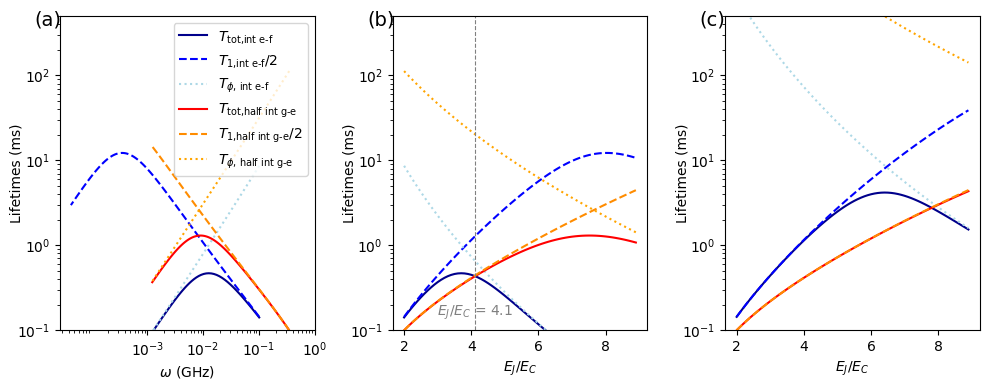

In [24]:
UIFQ_label='int e-f'
conventional_label='half int g-e'

fig,axes = plt.subplots(1,3,figsize = (10,4))

T_tot_ax = axes[0]
comparison_ax = axes[1]
comparison_small_1_over_f_ax = axes[2]





EL_idx = 20
EJ_over_EC_cutoff_idx = -31
EC_idx = 20

tot_results_temp = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
T1_results_temp = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
T1_dielectric_results_temp = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
T1_1overf_results_temp = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
Tphi_results_temp = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}

lifetimes = compute_lifetimes(one_over_f_flux_noise_amplitude = 1e-6,
                    temp_in_mK = 20, 
                    tangent_ref = 4e-6)

for catagory in ["conventional", "upside_down01", "upside_down12"]:
    dephasing_T = lifetimes[catagory+"_dephasing_lifetime"] / 1e6
    T1_tot = 2/(1/lifetimes[catagory+"_one_over_f_loss_lifetime"] + 1/lifetimes[catagory+"_dielectric_lifetime"])/1e6
    tot_results_temp[catagory].append(1/(2/T1_tot + 1/dephasing_T))
    Tphi_results_temp[catagory].append(dephasing_T)
    T1_results_temp[catagory].append(T1_tot)
    T1_dielectric_results_temp[catagory].append(lifetimes[catagory+"_dielectric_lifetime"]/1e6)
    T1_1overf_results_temp[catagory].append(lifetimes[catagory+"_one_over_f_loss_lifetime"]/1e6)
    noise_profile_idx = -1

def do_lifetimes():
    T_tot_ax.plot(frequencys["upside_down12"][EL_idx, :],tot_results_temp["upside_down12"][noise_profile_idx][EL_idx, :], label = rf'$T_{{\text{{tot,{UIFQ_label}}}}}$',color = 'darkblue')
    T_tot_ax.plot(frequencys["upside_down12"][EL_idx, :],T1_results_temp["upside_down12"][noise_profile_idx][EL_idx, :]/2, label = rf'$T_{{\text{{1,{UIFQ_label}}}}}$/2',color = 'blue', linestyle='dashed')
    T_tot_ax.plot(frequencys["upside_down12"][EL_idx, :],Tphi_results_temp["upside_down12"][noise_profile_idx][EL_idx, :], label = rf'$T_{{\phi \text{{, {UIFQ_label}}}}}$',color = 'lightblue', linestyle='dotted')
    T_tot_ax.plot(frequencys["conventional"][EL_idx, :],tot_results_temp["conventional"][noise_profile_idx][EL_idx, :], label = rf'$T_{{\text{{tot,{conventional_label}}}}}$',color = 'red')
    T_tot_ax.plot(frequencys["conventional"][EL_idx, :],T1_results_temp["conventional"][noise_profile_idx][EL_idx, :]/2, label = rf'$T_{{\text{{1,{conventional_label}}}}}/2$',color = 'darkorange', linestyle='dashed')
    T_tot_ax.plot(frequencys["conventional"][EL_idx, :],Tphi_results_temp["conventional"][noise_profile_idx][EL_idx, :], label = rf'$T_{{\phi \text{{, {conventional_label}}}}}$',color = 'orange', linestyle='dotted')
    # T_tot_ax.text(1e-4,5e0,"temporary Note: \n this is for 20 mK,  \n 1/f noise amplitude 1.4e-6, \n reference loss tangent 1e-5")
    T_tot_ax.legend(loc='upper right', ncol=1)
    T_tot_ax.set_xscale('log')
    T_tot_ax.set_yscale('log')
    T_tot_ax.set_ylim(1e-1,5e2)
    T_tot_ax.set_yticks([1e-1,1e0,1e1,1e2])
    T_tot_ax.set_xlabel(r'$\omega$ (GHz)')
    T_tot_ax.set_ylabel(rf'Lifetimes (ms)', labelpad=-5)

    # T_tot_ax.set_xlim(5e-5,1e2)
    T_tot_ax.set_xticks([1e-3,1e-2,1e-1,1])
do_lifetimes()


def do_comparison():
    comparison_ax.plot(EJ_over_EC_list[:EJ_over_EC_cutoff_idx], tot_results_temp["upside_down12"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx], label = rf'$T_{{\text{{tot,{UIFQ_label}}}}}$',color = 'darkblue')
    comparison_ax.plot(EJ_over_EC_list[:EJ_over_EC_cutoff_idx], T1_results_temp["upside_down12"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx]/2, label = rf'$T_{{\text{{1,{UIFQ_label}}}}}$/2',color = 'blue', linestyle='dashed')
    comparison_ax.plot(EJ_over_EC_list[:EJ_over_EC_cutoff_idx], Tphi_results_temp["upside_down12"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx], label = rf'$T_{{\phi \text{{, {UIFQ_label}}}}}$',color = 'lightblue', linestyle='dotted')

    comparison_ax.plot(EJ_over_EC_list[:EJ_over_EC_cutoff_idx], tot_results_temp["conventional"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx], label = rf'$T_{{\text{{tot,{conventional_label}}}}}$',color = 'red')
    comparison_ax.plot(EJ_over_EC_list[:EJ_over_EC_cutoff_idx], T1_results_temp["conventional"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx]/2, label = rf'$T_{{\text{{1,{conventional_label}}}}}/2$',color = 'darkorange', linestyle='dashed')
    comparison_ax.plot(EJ_over_EC_list[:EJ_over_EC_cutoff_idx], Tphi_results_temp["conventional"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx], label = rf'$T_{{\phi \text{{, {conventional_label}}}}}$',color = 'orange', linestyle='dotted')

    # comparison_ax.legend(loc='upper center', ncol=2)
    comparison_ax.set_yscale('log')
    comparison_ax.set_ylim(1e-1,5e2)
    comparison_ax.set_yticks([1e-1,1e0,1e1,1e2])
    comparison_ax.set_xlabel(r'$E_J/E_C$')
    comparison_ax.set_ylabel(rf'Lifetimes (ms)', labelpad=-5)

    UIFQ_minus_half = tot_results_temp["upside_down12"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx] - tot_results_temp["conventional"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx]
    sign_changes = np.diff(np.sign(UIFQ_minus_half))
    intersect_idx = np.where(sign_changes != 0)[0][0]
    comparison_ax.axvline(x=EJ_over_EC_list[intersect_idx], color='grey', linestyle='--',linewidth=0.8)
    comparison_ax.text(EJ_over_EC_list[intersect_idx],1.5e-1,rf"$E_J/E_C$ = {EJ_over_EC_list[intersect_idx]}", color='grey',ha = 'center')
do_comparison()

tot_results_temp = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
T1_results_temp = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
T1_dielectric_results_temp = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
T1_1overf_results_temp = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
Tphi_results_temp = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}

lifetimes = compute_lifetimes(one_over_f_flux_noise_amplitude = 1e-7,
                    temp_in_mK = 20, 
                    tangent_ref = 4e-6)

for catagory in ["conventional", "upside_down01", "upside_down12"]:
    dephasing_T = lifetimes[catagory+"_dephasing_lifetime"] / 1e6
    T1_tot = 2/(1/lifetimes[catagory+"_one_over_f_loss_lifetime"] + 1/lifetimes[catagory+"_dielectric_lifetime"])/1e6
    tot_results_temp[catagory].append(1/(2/T1_tot + 1/dephasing_T))
    Tphi_results_temp[catagory].append(dephasing_T)
    T1_results_temp[catagory].append(T1_tot)
    T1_dielectric_results_temp[catagory].append(lifetimes[catagory+"_dielectric_lifetime"]/1e6)
    T1_1overf_results_temp[catagory].append(lifetimes[catagory+"_one_over_f_loss_lifetime"]/1e6)
    noise_profile_idx = -1

def do_comparison_small_1_over_f():
    comparison_small_1_over_f_ax.plot(EJ_over_EC_list[:EJ_over_EC_cutoff_idx], tot_results_temp["upside_down12"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx], label = rf'$T_{{\text{{tot,{UIFQ_label}}}}}$',color = 'darkblue')
    comparison_small_1_over_f_ax.plot(EJ_over_EC_list[:EJ_over_EC_cutoff_idx], T1_results_temp["upside_down12"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx]/2, label = rf'$T_{{\text{{1,{UIFQ_label}}}}}$/2',color = 'blue', linestyle='dashed')
    comparison_small_1_over_f_ax.plot(EJ_over_EC_list[:EJ_over_EC_cutoff_idx], Tphi_results_temp["upside_down12"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx], label = rf'$T_{{\phi \text{{, {UIFQ_label}}}}}$',color = 'lightblue', linestyle='dotted')

    comparison_small_1_over_f_ax.plot(EJ_over_EC_list[:EJ_over_EC_cutoff_idx], tot_results_temp["conventional"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx], label = rf'$T_{{\text{{tot,{conventional_label}}}}}$',color = 'red')
    comparison_small_1_over_f_ax.plot(EJ_over_EC_list[:EJ_over_EC_cutoff_idx], T1_results_temp["conventional"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx]/2, label = rf'$T_{{\text{{1,{conventional_label}}}}}/2$',color = 'darkorange', linestyle='dashed')
    comparison_small_1_over_f_ax.plot(EJ_over_EC_list[:EJ_over_EC_cutoff_idx], Tphi_results_temp["conventional"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx], label = rf'$T_{{\phi \text{{, {conventional_label}}}}}$',color = 'orange', linestyle='dotted')

    # comparison_small_1_over_f_ax.legend(loc='upper center', ncol=2)
    comparison_small_1_over_f_ax.set_yscale('log')
    comparison_small_1_over_f_ax.set_ylim(1e-1,5e2)
    comparison_small_1_over_f_ax.set_yticks([1e-1,1e0,1e1,1e2])
    comparison_small_1_over_f_ax.set_xlabel(r'$E_J/E_C$')
    comparison_small_1_over_f_ax.set_ylabel(rf'Lifetimes (ms)', labelpad=-5)

    # UIFQ_minus_half = tot_results_temp["upside_down12"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx] - tot_results_temp["conventional"][noise_profile_idx][EL_idx, :EJ_over_EC_cutoff_idx]
    # sign_changes = np.diff(np.sign(UIFQ_minus_half))
    # intersect_idx = np.where(sign_changes != 0)[0][0]
    # comparison_small_1_over_f_ax.axvline(x=EJ_over_EC_list[intersect_idx], color='grey', linestyle='--',linewidth=0.8)
    # comparison_small_1_over_f_ax.text(EJ_over_EC_list[intersect_idx],1.5e-1,rf"$E_J/E_C$ = {EJ_over_EC_list[intersect_idx]}", color='grey',ha = 'center')
do_comparison_small_1_over_f()



T_tot_ax.text(-0.1, 1.02, '(a)', transform=T_tot_ax.transAxes, fontsize=14, verticalalignment='top')
comparison_ax.text(-0.1, 1.02, '(b)', transform=comparison_ax.transAxes, fontsize=14, verticalalignment='top')
comparison_small_1_over_f_ax.text(-0.1, 1.02, '(c)', transform=comparison_small_1_over_f_ax.transAxes, fontsize=14, verticalalignment='top')
plt.tight_layout()
plt.savefig('phi_element vs freq.pdf')

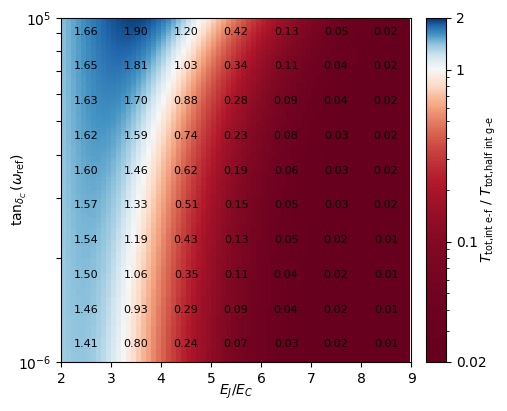

In [19]:
fig = plt.figure(figsize = (5,4))

heatmap_ax = fig.add_axes([0.1,0.1,0.7,0.86])
color_bar_ax= fig.add_axes([0.83,0.1,0.04,0.86])
ratio = tot_results['upside_down12'][:,EL_idx,:EJ_over_EC_cutoff_idx] / tot_results['conventional'][:,EL_idx,:EJ_over_EC_cutoff_idx]
# log_min = np.log10(np.min(ratio))
# log_max = np.log10(np.max(ratio))
# max_distance = max(abs(log_min), abs(log_max))
# max_distance = np.log10(2)
# vmin = 10**(-max_distance)
# vmax = 10**max_distance
# norm = LogNorm(vmin=vmin, vmax=vmax)
# cax = heatmap_ax.imshow(ratio, cmap = 'RdBu', norm=norm,
#         extent=[ EJ_over_EC_list[0], EJ_over_EC_list[EJ_over_EC_cutoff_idx],  list_of_ref_tangent[0], list_of_ref_tangent[-1]], aspect='auto',origin='lower'
#         )
from matplotlib import cm

import matplotlib.colors as mcolors
norm = mcolors.TwoSlopeNorm(vcenter=1,vmin = 0.02, 
                                      vmax = 2)
cax = heatmap_ax.imshow(ratio, cmap= 'RdBu', norm=norm,
        extent=[ EJ_over_EC_list[0], EJ_over_EC_list[EJ_over_EC_cutoff_idx],  list_of_ref_tangent[0], list_of_ref_tangent[-1]], aspect='auto',origin='lower'
        )
 
heatmap_ax.set_yscale('log')
cbar = fig.colorbar(cax, cax=color_bar_ax)
cbar.ax.set_yscale('log')
cbar.ax.set_yticks([0.02, 0.1, 1, 2])
cbar.ax.set_yticklabels(['0.02', '0.1', '1', '2'])
cbar.set_label(rf'$T_{{\text{{tot,{UIFQ_label}}}}}$ / $T_{{\text{{tot,{conventional_label}}}}}$',labelpad=-5)
heatmap_ax.set_xlabel(r'$E_J/E_C$',labelpad=-2)
heatmap_ax.set_ylabel(r'$\tan_{\delta_C} (\omega_\text{ref})$',labelpad=-8)
heatmap_ax.set_yticks([1e-6,2e-6,3e-6,4e-6,5e-6,6e-6,7e-6,8e-6,9e-6,1e-5])
heatmap_ax.set_yticklabels([r'$10^{-6}$','','','','',
                            '','','','',r'$10^{5}$'])
# heatmap_ax.text(2.5,8e-6,'int e-f advantageous' ,color='darkblue')
# heatmap_ax.text(5,1.8e-6,'half int g-e advantageous' ,color='darkred')
for i in range(ratio.shape[0])[5::10]:
    for j in range(ratio.shape[1])[5::10]:
        heatmap_ax.text(EJ_over_EC_list[j], 
                list_of_ref_tangent[i],f"{ratio[i,j]:.2f}",ha='center',va='center',size=8)
plt.savefig('heatmap.pdf')

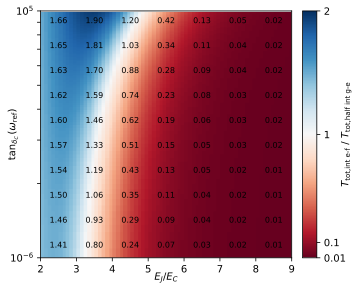

In [141]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import FuncNorm

def forward(v, vmin, vcenter, vmax):
    """ Forward transformation function for asymmetric log scaling. """
    v = np.clip(v, vmin, vmax)  # Ensure v is within the bounds
    return np.where(
        v < vcenter,
        np.log10(v - vmin + 1) / np.log10(vcenter - vmin + 1) / 2,
        0.5 + np.log10(v - vcenter + 1) / np.log10(vmax - vcenter + 1) / 2
    )

def inverse(value, vmin, vcenter, vmax):
    """ Inverse transformation function to convert back from normalized value. """
    return np.where(
        value < 0.5,
        vmin + (10 ** (value * 2 * np.log10(vcenter - vmin + 1))) - 1,
        vcenter + (10 ** ((value - 0.5) * 2 * np.log10(vmax - vcenter + 1))) - 1
    )

vmin = 0.01
vcenter = 1
vmax = 2

# Create FuncNorm instance with the forward and inverse functions
norm = FuncNorm((lambda v: forward(v, vmin, vcenter, vmax), 
                 lambda value: inverse(value, vmin, vcenter, vmax)),
                vmin=vmin, vmax=vmax)




fig = plt.figure(figsize = (5,4))

heatmap_ax = fig.add_axes([0.1,0.1,0.7,0.86])
color_bar_ax= fig.add_axes([0.83,0.1,0.04,0.86])
ratio = tot_results['upside_down12'][:,EL_idx,:EJ_over_EC_cutoff_idx] / tot_results['conventional'][:,EL_idx,:EJ_over_EC_cutoff_idx]


cax = heatmap_ax.imshow(ratio, cmap= 'RdBu', norm=norm,
        extent=[ EJ_over_EC_list[0], EJ_over_EC_list[EJ_over_EC_cutoff_idx],  list_of_ref_tangent[0], list_of_ref_tangent[-1]], aspect='auto',origin='lower'
        )
 


heatmap_ax.set_yscale('log')
cbar = fig.colorbar(cax, cax=color_bar_ax, ticks=[0.01, 0.1, 1, 2])
cbar.ax.set_yticklabels(['0.01', '0.1', '1', '2'])
# cbar.ax.set_yscale('log')
cbar.set_label(rf'$T_{{\text{{tot,{UIFQ_label}}}}}$ / $T_{{\text{{tot,{conventional_label}}}}}$',labelpad=-5)
heatmap_ax.set_xlabel(r'$E_J/E_C$',labelpad=-2)
heatmap_ax.set_ylabel(r'$\tan_{\delta_C} (\omega_\text{ref})$',labelpad=-8)
heatmap_ax.set_yticks([1e-6,2e-6,3e-6,4e-6,5e-6,6e-6,7e-6,8e-6,9e-6,1e-5])
heatmap_ax.set_yticklabels([r'$10^{-6}$','','','','',
                            '','','','',r'$10^{5}$'])
# heatmap_ax.text(2.5,8e-6,'int e-f advantageous' ,color='darkblue')
# heatmap_ax.text(5,1.8e-6,'half int g-e advantageous' ,color='darkred')
for i in range(ratio.shape[0])[5::10]:
    for j in range(ratio.shape[1])[5::10]:
        heatmap_ax.text(EJ_over_EC_list[j], 
                list_of_ref_tangent[i],f"{ratio[i,j]:.2f}",ha='center',va='center',size=8)
plt.savefig('heatmap.pdf')

In [121]:
tot_results['upside_down12'].shape

(100, 51, 101)

In [122]:
list_of_ref_tangent[-1]

1e-05

In [ ]:
for i in range(len(EJ_over_EL_list)):
    for j in range(len(EJ_over_EC_list)):
        EC = EJ / EJ_over_EC_list[j]
        EL = EJ / EJ_over_EL_list[i]


i =EL_idx
omega_conventional = conventional_freq_array[i, :] * 2 * np.pi
second_order_conventional = conventional_2nd_order_array[i, :]

omega_upside_down12 = upside_down_freq12_array[i, :] * 2 * np.pi
second_order_upside_down12 = upside_down_2nd_order_12_array[i, :]


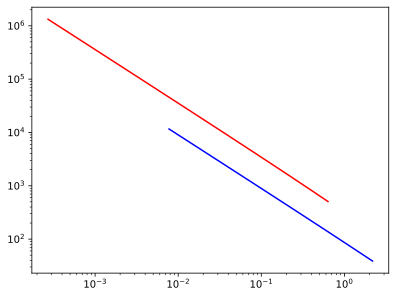

In [198]:

plt.plot(omega_conventional,second_order_conventional,color='blue')
plt.plot(omega_upside_down12,second_order_upside_down12,color='red')

plt.yscale('log')
plt.xscale('log')

In [241]:
0.362 / (  4*np.pi**2 * 0.135)

0.06792271940467828

In [240]:
0.19 / (  4*np.pi**2 * 0.175 )

0.027501464131491682

In [251]:
EL_idx

20

30.0


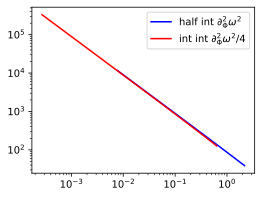

In [270]:
i =20

print(EJ_over_EL_list[i])

omega_conventional = conventional_freq_array[i, :] * 2 * np.pi
second_order_conventional = conventional_2nd_order_array[i, :]

omega_upside_down12 = upside_down_freq12_array[i, :] * 2 * np.pi
second_order_upside_down12 = upside_down_2nd_order_12_array[i, :]


plt.figure(figsize=(4,3))
plt.plot(omega_conventional,second_order_conventional,color='blue',label=r'half int $\partial_{\Phi}^2 \omega^2 $')
plt.plot(omega_upside_down12,second_order_upside_down12/4,color='red',label=r'int int $\partial_{\Phi}^2 \omega^2 $/4')

plt.yscale('log')
plt.xscale('log')
plt.legend()

In [210]:
qbt = scqubits.Fluxonium(EJ = 3,EC = 3/4,EL = 3/30, cutoff = 110,flux = 0,truncated_dim=4)
fluxvals = np.linspace(0.25, 1.25, 180)
specdata  =  qbt.get_spectrum_vs_paramvals(param_name='flux', param_vals=fluxvals)

Spectral data:   0%|          | 0/180 [00:00<?, ?it/s]

In [213]:
specdata.energy_table.shape

(180, 6)